# Loading and preprocessing sentiment output

# Import sentiment and original tweet

In [8]:
import numpy as np
import pandas as pd

batches = []  # list of dataframes
for i in range(23):
    df = pd.read_csv(f'elon_batch_{i}.csv', parse_dates=['date'])
    batches.append(df)


In [159]:
DF = pd.concat(batches, ignore_index=True,axis=0)

In [102]:
import pandas as pd
file_path = 'elonmusk.csv'
Data = pd.read_csv(file_path, parse_dates=['Datetime'], index_col='Datetime')

# Create a trading calendar
NASDAQ close at 9:00 pm and weekends. So one market day go from a close to the next one.

In [ ]:
# Import all the information on date
import pandas as pd
file_path = 'elonmusk.csv'
Data = pd.read_csv(file_path, parse_dates=['Datetime'], index_col='Datetime')

In [167]:
DF.index = Data.index

In [161]:
# sentiment with exact date
DF.head()

,date,negative,neutral,positive
0,2023-06-29,0.01,0.70,0.29
1,2023-06-29,0.02,0.70,0.28
2,2023-06-29,0.30,0.10,0.60
3,2023-06-29,0.01,0.04,0.95
4,2023-06-28,0.01,0.04,0.95


In [185]:
# first and last tweet day
first = DF.iloc[-1]['date']
print(first)
last = DF.iloc[1]['date']
print(last)

2023-06-29 00:00:00
2011-12-01 00:00:00


In [187]:
import yfinance as yf
ticker = 'TSLA'
tesla = yf.download(tickers=ticker, start='2011-12-01', end='2023-06-30')

C:\Users\carlo\AppData\Local\Temp\ipykernel_20260\1665831815.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla = yf.download(tickers=ticker, start='2011-12-01', end='2023-06-30')
[*********************100%***********************]  1 of 1 completed


In [191]:
tesla=tesla.xs('TSLA',axis=1,level=1)
tesla.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-06-23,256.600006,262.450012,252.800003,259.290009,177460800
2023-06-26,241.050003,258.369995,240.699997,250.070007,179990600
2023-06-27,250.210007,250.389999,240.850006,243.240005,164968200
2023-06-28,256.239990,259.880005,248.889999,249.699997,159770800
2023-06-29,257.500000,260.739990,253.610001,258.029999,131283400


In [193]:
# market calendar
market_close = tesla.index + pd.Timedelta(hours=21)

In [195]:
tesla['market_close'] = market_close
tesla = tesla.set_index('market_close')

In [197]:
# same order
tesla = tesla.sort_index(ascending=True)
DF = DF.sort_index(ascending=True)

In [199]:
# same date time
tesla = tesla.copy()
tesla.index = tesla.index.tz_localize('UTC')

# Allocate tweets in the appropriate market day

In [209]:
tesla
tesla_ind = tesla.copy()
tesla_ind['market_data'] = tesla_ind.index 
tesla_ind

Price,Close,High,Low,Open,Volume,market_data
market_close,,,,,,
2011-12-01 21:00:00+00:00,2.173333,2.266000,2.132000,2.171333,15453000,2011-12-01 21:00:00+00:00
2011-12-02 21:00:00+00:00,2.220000,2.246000,2.160000,2.188667,12042000,2011-12-02 21:00:00+00:00
2011-12-05 21:00:00+00:00,2.294667,2.333333,2.228667,2.235333,17401500,2011-12-05 21:00:00+00:00
2011-12-06 21:00:00+00:00,2.324667,2.332000,2.268667,2.280000,14277000,2011-12-06 21:00:00+00:00
2011-12-07 21:00:00+00:00,2.279333,2.326000,2.253333,2.308667,10114500,2011-12-07 21:00:00+00:00
...,...,...,...,...,...,...
2023-06-23 21:00:00+00:00,256.600006,262.450012,252.800003,259.290009,177460800,2023-06-23 21:00:00+00:00
2023-06-26 21:00:00+00:00,241.050003,258.369995,240.699997,250.070007,179990600,2023-06-26 21:00:00+00:00
2023-06-27 21:00:00+00:00,250.210007,250.389999,240.850006,243.240005,164968200,2023-06-27 21:00:00+00:00


In [171]:
DF = DF.sort_index(ascending=True)
DF

,date,negative,neutral,positive
Datetime,,,,
2010-06-04 18:31:57+00:00,2010-06-04,0.05,0.65,0.30
2011-12-01 09:55:11+00:00,2011-12-01,0.01,0.04,0.95
2011-12-01 10:29:04+00:00,2011-12-01,0.00,0.15,0.85
2011-12-03 08:20:28+00:00,2011-12-03,0.05,0.10,0.85
2011-12-03 08:22:07+00:00,2011-12-03,0.23,0.75,0.02
...,...,...,...,...
2023-06-28 18:05:58+00:00,2023-06-28,0.01,0.04,0.95
2023-06-29 01:19:59+00:00,2023-06-29,0.01,0.04,0.95
2023-06-29 03:46:37+00:00,2023-06-29,0.30,0.10,0.60


In [211]:
result = pd.merge_asof(
    DF, 
    tesla_ind, 
    left_index=True,
    right_index=True,
    direction='forward' 
)

In [217]:
result['sentiment'] = result['positive']-result['negative']

In [219]:
result

,date,negative,neutral,positive,Close,High,Low,Open,Volume,market_data,sentiment
Datetime,,,,,,,,,,,
2010-06-04 18:31:57+00:00,2010-06-04,0.05,0.65,0.30,2.173333,2.266000,2.132000,2.171333,15453000,2011-12-01 21:00:00+00:00,0.25
2011-12-01 09:55:11+00:00,2011-12-01,0.01,0.04,0.95,2.173333,2.266000,2.132000,2.171333,15453000,2011-12-01 21:00:00+00:00,0.94
2011-12-01 10:29:04+00:00,2011-12-01,0.00,0.15,0.85,2.173333,2.266000,2.132000,2.171333,15453000,2011-12-01 21:00:00+00:00,0.85
2011-12-03 08:20:28+00:00,2011-12-03,0.05,0.10,0.85,2.294667,2.333333,2.228667,2.235333,17401500,2011-12-05 21:00:00+00:00,0.80
2011-12-03 08:22:07+00:00,2011-12-03,0.23,0.75,0.02,2.294667,2.333333,2.228667,2.235333,17401500,2011-12-05 21:00:00+00:00,-0.21
...,...,...,...,...,...,...,...,...,...,...,...
2023-06-28 18:05:58+00:00,2023-06-28,0.01,0.04,0.95,256.239990,259.880005,248.889999,249.699997,159770800,2023-06-28 21:00:00+00:00,0.94
2023-06-29 01:19:59+00:00,2023-06-29,0.01,0.04,0.95,257.500000,260.739990,253.610001,258.029999,131283400,2023-06-29 21:00:00+00:00,0.94
2023-06-29 03:46:37+00:00,2023-06-29,0.30,0.10,0.60,257.500000,260.739990,253.610001,258.029999,131283400,2023-06-29 21:00:00+00:00,0.30


# Extract information
I create a Dataframe composed by market day, average sentiment, tweet count, logreturn, volume.

In [222]:
DF_group = result.groupby('market_data').agg(
    Average_sentimen = ('sentiment','mean'),
    Tweet_count = ('sentiment','count'),
    Close = ('Close','mean'),
    Volume = ('Volume','mean')
)

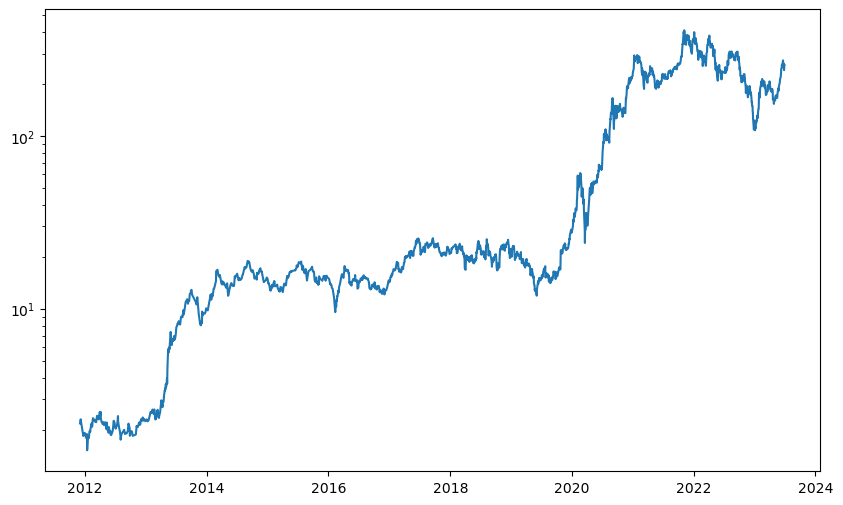

In [236]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(DF_group['Close'])
plt.yscale('log')

In [242]:
ln_returns = (np.log(DF_group['Close'])).diff()
DF_full = pd.merge( DF_group,ln_returns,left_index=True,right_index=True,how='left')

In [252]:
DF_full = DF_full[1:] # drop first row because of nan

In [256]:
DF_full.rename(columns={'Close_x':'Close','Close_y':'LogReturns'}, inplace=True)

C:\Users\carlo\AppData\Local\Temp\ipykernel_20260\1666206583.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_full.rename(columns={'Close_x':'Close','Close_y':'LogReturns'}, inplace=True)


In [291]:
DF_full['Sign'] = np.where(DF_full['LogReturns']>0,1,0)

C:\Users\carlo\AppData\Local\Temp\ipykernel_20260\2898653989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_full['Sign'] = np.where(DF_full['LogReturns']>0,1,0)


In [293]:
DF_full

,Average_sentimen,Tweet_count,Close,Volume,LogReturns,Sign
market_data,,,,,,
2011-12-05 21:00:00+00:00,0.510000,3,2.294667,17401500.0,0.054326,1
2011-12-21 21:00:00+00:00,0.093333,6,1.838000,25582500.0,-0.221910,0
2011-12-22 21:00:00+00:00,0.668750,4,1.851333,15141000.0,0.007228,1
2011-12-27 21:00:00+00:00,0.175000,8,1.904667,11662500.0,0.028401,1
2011-12-28 21:00:00+00:00,0.880000,1,1.900667,8628000.0,-0.002102,0
...,...,...,...,...,...,...
2023-06-23 21:00:00+00:00,0.763333,6,256.600006,177460800.0,-0.030739,0
2023-06-26 21:00:00+00:00,0.244070,86,241.050003,179990600.0,-0.062514,0
2023-06-27 21:00:00+00:00,0.245517,29,250.210007,164968200.0,0.037296,1


# Save file 

In [295]:
DF_full.to_csv('Full_DF_for_LSTM.csv')